**PRÁCTICA 2**

Integrantes:
   

  
   - Paula García
   - Valentina Morales

In [1]:
import numpy as np
import scipy.io as sio

#Array de ejemplo
h=np.array([3,4])

Esta es la forma larga de implementar la función:

In [2]:
def rms(x):
    cuadrados = x**2              # eleva cada muestra de la señal al cuadrado
    suma = np.sum(cuadrados)      # suma todos los valores cuadrados en un solo número
    promedio = suma / len(x)      # divide esa suma entre N (cantidad de muestras)
    valor_rms = np.sqrt(promedio) # saca la raíz cuadrada del promedio
    return valor_rms


rms(h)

np.float64(3.5355339059327378)

Esta es la manera corta y ya existente:

In [4]:
def rms(x):
    return np.sqrt(np.mean(x**2))

rms(h)

np.float64(3.5355339059327378)

En el siguiente código, cargo el archivo .mat y verifico que claves tiene

In [5]:
data = sio.loadmat("signals.mat")
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


In [6]:
for clave in data.keys():
    if not clave.startswith("__"):   # ignora metadatos internos de scipy
        print(clave, "-> forma:", data[clave].shape, "| tipo:", data[clave].dtype)

Fs -> forma: (1, 1) | tipo: uint16
ECG_asRecording -> forma: (1, 30720) | tipo: float64
ECG_filtered -> forma: (1, 30720) | tipo: float64
EMG_filtered1 -> forma: (1, 30721) | tipo: float64
EMG_filtered2 -> forma: (1, 30721) | tipo: float64
EMG_asRecording1 -> forma: (1, 30721) | tipo: float64
EMG_asRecording2 -> forma: (1, 30721) | tipo: float64


•	A partir de la información suministrada en el archivo .mat, determine el tiempo de duración de las señales, cree un vector de tiempo. 

In [7]:
fs = int(data["Fs"][0,0])                             # frecuencia de muestreo (1024 Hz)
ecg_sin_filtrar = data["ECG_asRecording"].flatten()    # ECG sin filtrar, vector 1D
ecg_filtrada = data["ECG_filtered"].flatten()          # ECG filtrada, vector 1D

print("Fs:", fs, "Hz")
print("Forma de ecg_sin_filtrar:", ecg_sin_filtrar.shape)

N = len(ecg_sin_filtrar)        # número total de muestras
duracion = N / fs                # duración total en segundos
t = np.arange(N) / fs            # vector de tiempo (un valor por muestra)

print("Número de muestras:", N)
print("Duración de la señal:", duracion, "segundos")

Fs: 1024 Hz
Forma de ecg_sin_filtrar: (30720,)
Número de muestras: 30720
Duración de la señal: 30.0 segundos


•	Grafique la señal sin filtrar y filtrada, compárelas. Comente lo que observa, y describa cómo debe ser el comportamiento del filtro que se utilizó. Recuerde las frecuencias de interés de la señal ECG.

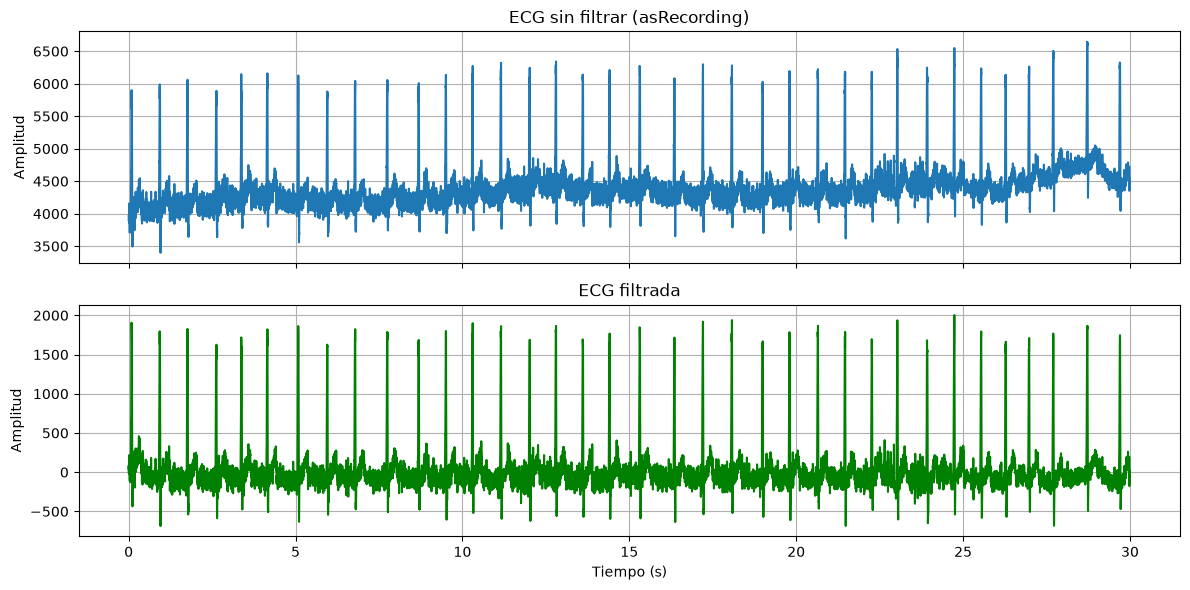

Media sin filtrar: 4381.171892023087
Media filtrada: 3.177639664609484
Rango sin filtrar: 3398.603759765625 a 6643.640625
Rango filtrada: -685.6954452075946 a 2003.3280873578112


In [8]:
import matplotlib.pyplot as plt

# --- Gráfica comparativa: ECG sin filtrar vs. filtrada ---
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(12, 6))

axs[0].plot(t, ecg_sin_filtrar)
axs[0].set_title("ECG sin filtrar (asRecording)")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)

axs[1].plot(t, ecg_filtrada, color='green')
axs[1].set_title("ECG filtrada")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Amplitud")
axs[1].grid(True)

plt.tight_layout()
plt.show()

# --- Estadísticos básicos para respaldar el análisis ---
print("Media sin filtrar:", np.mean(ecg_sin_filtrar))
print("Media filtrada:", np.mean(ecg_filtrada))
print("Rango sin filtrar:", ecg_sin_filtrar.min(), "a", ecg_sin_filtrar.max())
print("Rango filtrada:", ecg_filtrada.min(), "a", ecg_filtrada.max())

Ahora, un zoom en los 3 primeros segundos para observar mas a detalle cada señal:

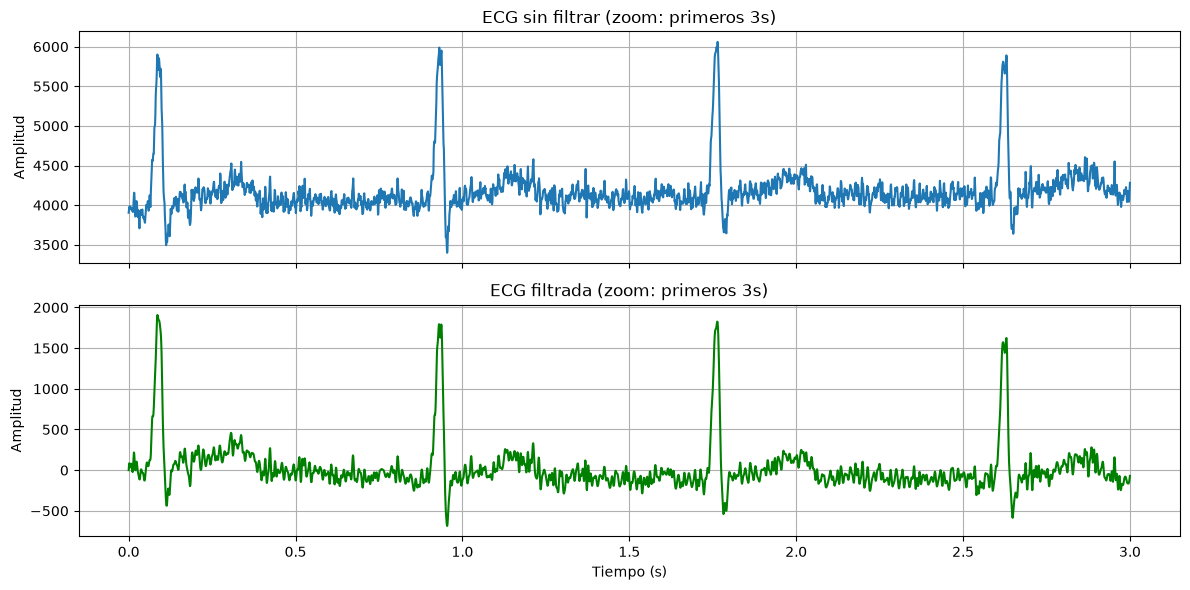

In [9]:
fig2, axs2 = plt.subplots(2, 1, sharex=True, figsize=(12, 6))
mask = t <= 3   # selecciona solo los puntos donde el tiempo es <= 3 segundos

axs2[0].plot(t[mask], ecg_sin_filtrar[mask])
axs2[0].set_title("ECG sin filtrar (zoom: primeros 3s)")
axs2[0].set_ylabel("Amplitud")
axs2[0].grid(True)

axs2[1].plot(t[mask], ecg_filtrada[mask], color='green')
axs2[1].set_title("ECG filtrada (zoom: primeros 3s)")
axs2[1].set_xlabel("Tiempo (s)")
axs2[1].set_ylabel("Amplitud")
axs2[1].grid(True)

plt.tight_layout()
plt.show()


**Análisis:**

El filtro que se aplicó a la señal parece ser un filtro pasa-banda, es decir, uno que deja pasar solo un rango específico de frecuencias y elimina lo que está por fuera de ese rango, tanto muy bajo como muy alto.

Por un lado, se eliminó el desplazamiento constante que tenía la señal original (la media pasó de 4381 a casi 0), así como las variaciones lentas de fondo que se ven en la línea base entre un latido y otro. Esto sugiere que el filtro bloqueó las frecuencias muy bajas, algo típico en el procesamiento de señales de ECG, ya que ese tipo de variación lenta suele deberse a la respiración o al movimiento de los electrodos, no al corazón en sí.

Por otro lado, al comparar el ruido que se ve entre los picos de cada latido, la señal filtrada se ve más "limpia" que la señal original, lo que indica que también se eliminaron las frecuencias muy altas — probablemente ruido muscular o interferencia eléctrica. Esto es coherente con que la parte más importante del latido (el pico QRS) se concentra en un rango de frecuencias intermedio, así que el filtro dejó esa parte intacta y solo limpió lo que estaba antes y después de ese rango.

---

•	Tome la señal tal cual se registró. De dicha señal, seleccione un ciclo cardiaco, grafique. Calcule el promedio, el valor RMS, la varianza y la desviación estándar del ciclo. Analice los resultados.

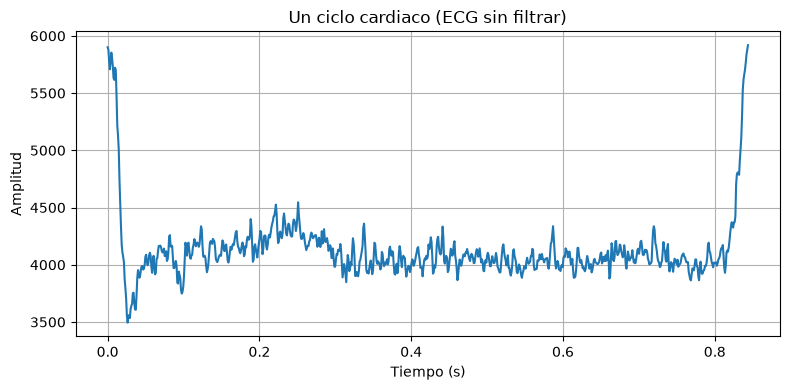

Duración del ciclo: 0.84375 segundos
Media: 4131.136266878161
RMS: 4142.454957820607
Varianza: 93646.2220564969
Desviación estándar: 306.01670225086883


In [10]:
from scipy.signal import find_peaks

#Detectar los picos R (los máximos de cada complejo QRS)
picos, _ = find_peaks(ecg_sin_filtrar, height=5500, distance=fs*0.5) #Separados minimamente 0.5 segundos

inicio = picos[0]
fin = picos[1]
ciclo = ecg_sin_filtrar[inicio:fin]
t_ciclo = t[inicio:fin] - t[inicio]

#Graficar el ciclo
plt.figure(figsize=(8, 4))
plt.plot(t_ciclo, ciclo)
plt.title("Un ciclo cardiaco (ECG sin filtrar)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

#Estadísticos del ciclo
media = np.mean(ciclo)
valor_rms = rms(ciclo)         
varianza = np.var(ciclo)
desviacion = np.std(ciclo)

print("Duración del ciclo:", t_ciclo[-1], "segundos")
print("Media:", media)
print("RMS:", valor_rms)
print("Varianza:", varianza)
print("Desviación estándar:", desviacion)

**Análisis**

Al extraer un ciclo cardiaco individual de la señal sin filtrar, se observa que la media (4131.14) y el valor RMS (4142.45) son prácticamente iguales. Esto se debe a que la señal sin filtrar mantiene un offset considerable, oscilando siempre en valores positivos alrededor de 4000-4200, sin cruzar por cero. Como el RMS se calcula a partir de los valores al cuadrado, cuando una señal no tiene simetría alrededor de cero (como en este caso), su valor tiende a acercarse mucho al de la media simple. La desviación estándar (306.02) refleja la variabilidad relativamente moderada de la señal alrededor de su valor promedio, incluyendo tanto el pico pronunciado del complejo QRS como las fluctuaciones de menor amplitud del resto del ciclo.


---

•	Tome la señal filtrada. Repita el procedimiento anterior con esta señal, compare con los resultados obtenidos en el ítem anterior. 

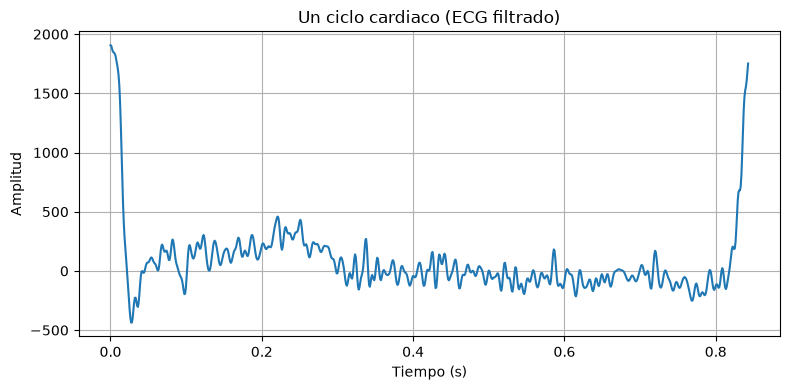

Duración del ciclo: 0.8427734375 segundos
Media: 74.00995782055861
RMS: 319.62757818893766
Varianza: 96684.31488232457
Desviación estándar: 310.94101511753735


In [11]:
#Detectar los picos R (los máximos de cada complejo QRS)
picos, _ = find_peaks(ecg_filtrada, height=1000, distance=fs*0.5) #Separados minimamente 0.5 segundos


inicio = picos[0]
fin = picos[1]
ciclo2 = ecg_filtrada[inicio:fin]
t_ciclo2 = t[inicio:fin] - t[inicio]

#Graficar el ciclo
plt.figure(figsize=(8, 4))
plt.plot(t_ciclo2, ciclo2)
plt.title("Un ciclo cardiaco (ECG filtrado)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

#Estadísticos del ciclo
media2 = np.mean(ciclo2)
valor_rms2 = rms(ciclo2)         
varianza2 = np.var(ciclo2)
desviacion2 = np.std(ciclo2)

print("Duración del ciclo:", t_ciclo2[-1], "segundos")
print("Media:", media2)
print("RMS:", valor_rms2)
print("Varianza:", varianza2)
print("Desviación estándar:", desviacion2)

**Análisis**
Al comparar los estadísticos del ciclo cardiaco antes y después del filtrado, se observan diferencias importantes que confirman el efecto del filtro sobre la señal.

La media cae drásticamente de 4131.14 a 75.99, evidenciando la eliminación del offset presente en la señal original. En la señal sin filtrar, la media y el RMS son prácticamente iguales (4131.14 vs 4142.45), ya que al no cruzar por cero, no hay valores negativos que compensen el promedio. En cambio, en la señal filtrada, la media y el RMS se distancian considerablemente (75.99 vs 325.22): al oscilar simétricamente alrededor de cero, los valores positivos y negativos se cancelan al promediar (media cercana a cero), mientras que el RMS,al elevar al cuadrado antes de promedia,no sufre esta cancelación y refleja correctamente la magnitud real de la señal.

Por otro lado, la varianza y la desviación estándar se mantienen muy similares entre ambas versiones (93646.22 vs 99990.67 para la varianza; 306.02 vs 316.21 para la desviación estándar). Esto tiene sentido, ya que la varianza mide la dispersión de los datos respecto a su propia media (no respecto a cero), por lo que no se ve afectada por el desplazamiento (offset) que el filtro eliminó.

---


•	Extraiga 15 ciclos de la señal filtrada, y para cada ciclo calcule el valor promedio y la varianza, grafique cada ciclo, y analice (gráfica y estadísticamente). ¿Se puede considerar que la señal es estacionaria? 

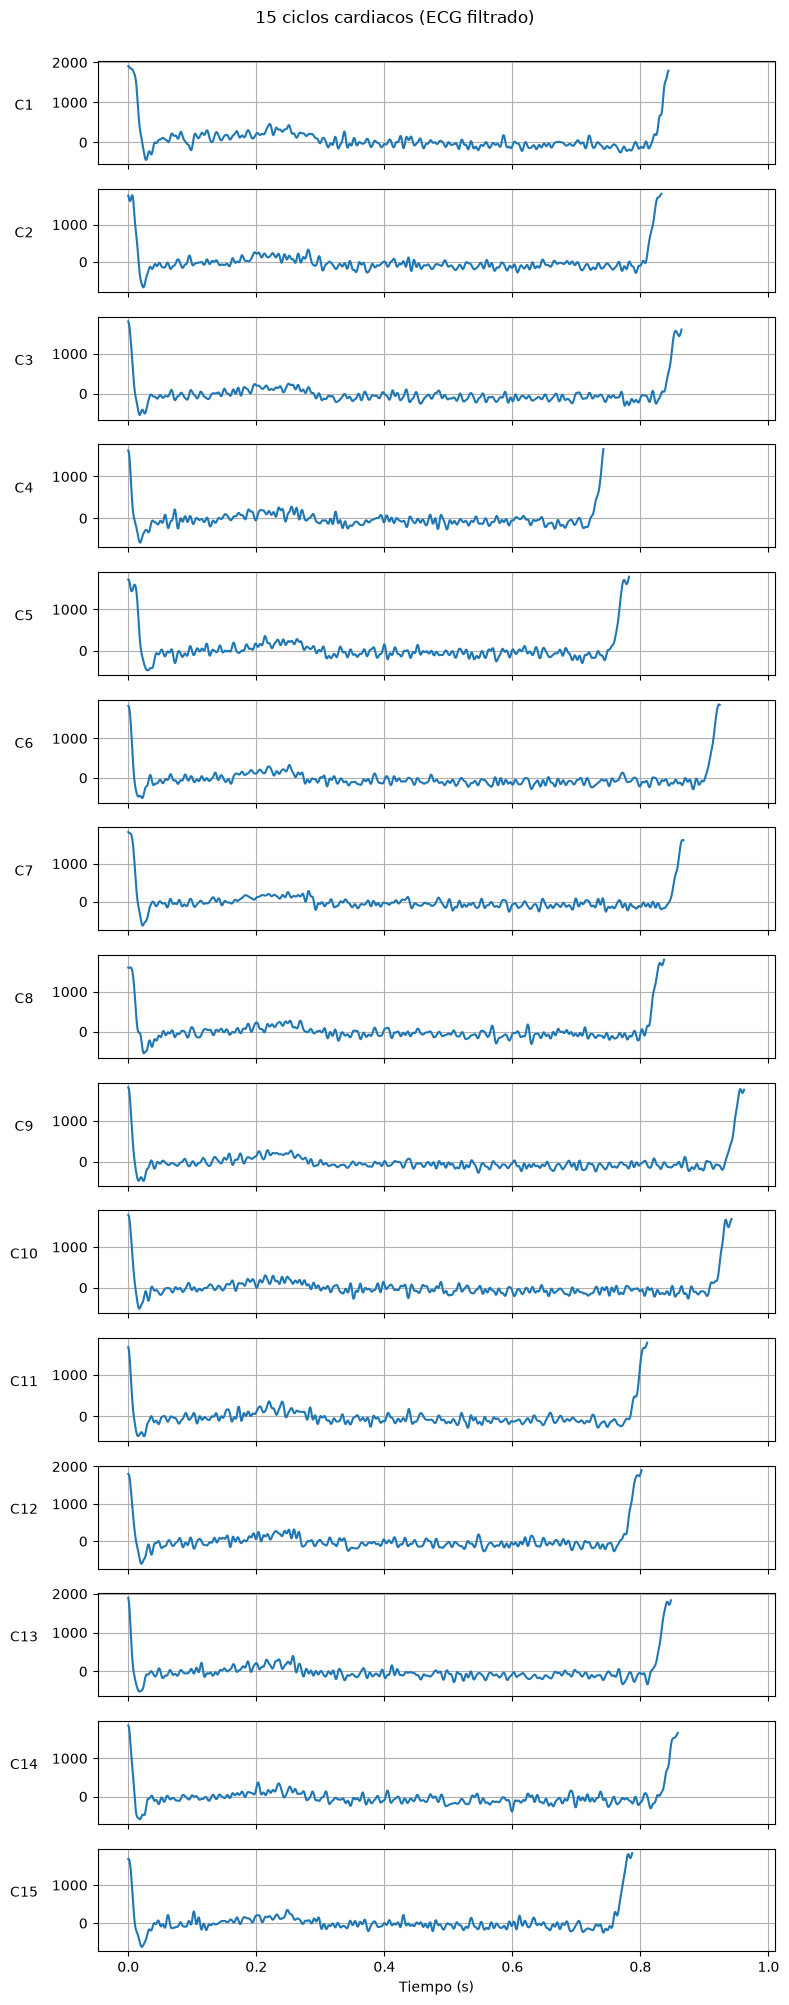

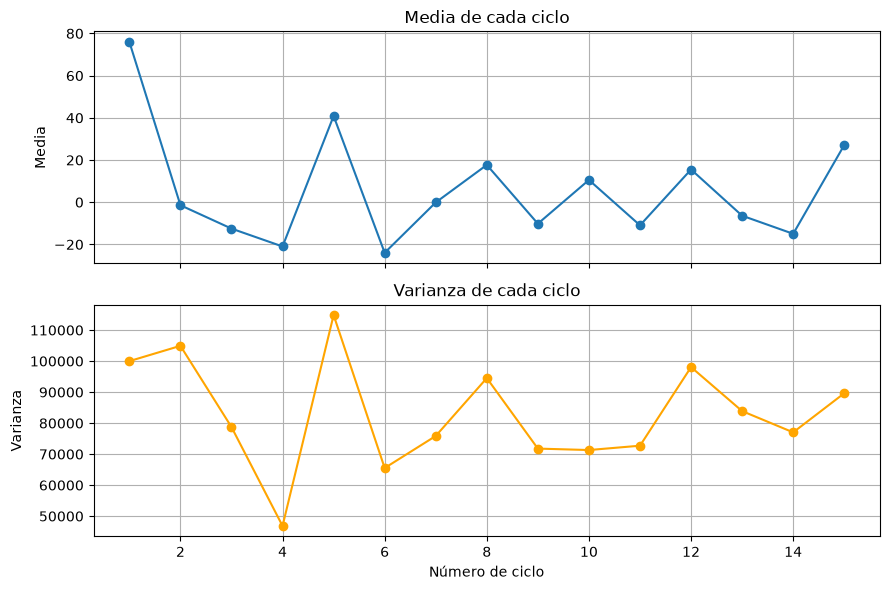

Medias de los 15 ciclos: [ 76.    -1.43 -12.51 -20.98  40.87 -23.96  -0.1   17.68 -10.18  10.55
 -10.95  15.51  -6.39 -14.97  27.11]
Varianzas de los 15 ciclos: [ 99990.67 104925.82  78731.93  46839.02 114850.02  65519.06  75856.24
  94521.53  71784.96  71319.48  72718.43  98071.8   83877.51  77022.13
  89636.94]

Media de las medias: 5.750634517664811 | Desv. estándar de las medias: 25.83314197011141
Media de las varianzas: 83044.36856674009 | Desv. estándar de las varianzas: 16881.249914894117


In [12]:
from scipy.signal import find_peaks

# ============================================================
# 1. Detectar picos R y extraer los 15 ciclos de la señal filtrada
# ============================================================
picos, _ = find_peaks(ecg_sin_filtrar, height=5500, distance=fs*0.5)
picos_15 = picos[:16]   # 16 picos -> 15 ciclos

ciclos = []
medias = []
varianzas = []

for i in range(15):
    inicio = picos_15[i]
    fin = picos_15[i+1]
    ciclo = ecg_filtrada[inicio:fin]
    ciclos.append(ciclo)
    medias.append(np.mean(ciclo))
    varianzas.append(np.var(ciclo))

medias = np.array(medias)
varianzas = np.array(varianzas)

# ============================================================
# 2. Graficar los 15 ciclos, uno debajo del otro
# ============================================================
fig, axs = plt.subplots(15, 1, figsize=(8, 20), sharex=True)

for i, ciclo in enumerate(ciclos):
    t_c = np.arange(len(ciclo)) / fs
    axs[i].plot(t_c, ciclo)
    axs[i].set_ylabel(f"C{i+1}", rotation=0, labelpad=20)
    axs[i].grid(True)

axs[-1].set_xlabel("Tiempo (s)")
fig.suptitle("15 ciclos cardiacos (ECG filtrado)", y=1.0)
plt.tight_layout()
plt.show()

# ============================================================
# 3. Graficar la evolución de media y varianza a través de los ciclos
# ============================================================
fig2, axs2 = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axs2[0].plot(range(1, 16), medias, marker='o')
axs2[0].set_title("Media de cada ciclo")
axs2[0].set_ylabel("Media")
axs2[0].grid(True)

axs2[1].plot(range(1, 16), varianzas, marker='o', color='orange')
axs2[1].set_title("Varianza de cada ciclo")
axs2[1].set_xlabel("Número de ciclo")
axs2[1].set_ylabel("Varianza")
axs2[1].grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# 4. Estadísticos resumen (para respaldar el análisis)
# ============================================================
print("Medias de los 15 ciclos:", np.round(medias, 2))
print("Varianzas de los 15 ciclos:", np.round(varianzas, 2))
print()
print("Media de las medias:", np.mean(medias), "| Desv. estándar de las medias:", np.std(medias))
print("Media de las varianzas:", np.mean(varianzas), "| Desv. estándar de las varianzas:", np.std(varianzas))

**Análisis gráfico**

Al graficar los 15 ciclos individualmente, se observa un patrón morfológico muy consistente entre ellos: todos presentan el mismo pico QRS pronunciado al inicio (con amplitud cercana a 1800-2000), seguido de una zona de menor amplitud con fluctuaciones de ruido similares. No se aprecia ningún cambio sistemático en la forma o amplitud de los ciclos a medida que avanza el tiempo (es decir, los ciclos del final de la señal, como C13-C15, no se ven sistemáticamente distintos a los del inicio, como C1-C3).

**Análisis estadístico**

La media de cada ciclo individual oscila entre -23.96 y 76.0, con una media global de 5.75 y una desviación estándar de 25.83 entre las 15 medias. Esta variabilidad es pequeña comparada con la amplitud típica del ciclo (que supera 1800 en el pico QRS), lo cual sugiere que la media no presenta una deriva sistemática relevante a lo largo del tiempo.

La varianza de cada ciclo oscila entre 46839.02 y 114850.02, con una media global de 83044.37 y una desviación estándar de 16881.25 (equivalente a un coeficiente de variación de aproximadamente 20%). Si bien existe cierta variabilidad ciclo a ciclo, no se observa una tendencia sistemática de aumento o disminución progresiva a lo largo de los 15 ciclos, los valores fluctúan de forma aparentemente aleatoria alrededor de su media global.

**Conclusión — ¿es estacionaria?**

Con base en la evidencia gráfica (morfología consistente entre ciclos) y estadística (media y varianza fluctuando sin tendencia sistemática alrededor de valores relativamente estables), la señal ECG filtrada puede considerarse aproximadamente estacionaria en sentido amplio (weak-sense stationary) dentro de esta ventana de análisis de 15 ciclos. No obstante, esta conclusión se basa en una inspección visual y descriptiva; en los siguientes puntos del laboratorio se aplicarán pruebas estadísticas formales (prueba t, Levene, y Dickey-Fuller) para confirmar esta hipótesis con mayor rigor estadístico.

---

•	Realice dos veces comparaciones entre dos ciclos cualquiera utilizando una prueba t. Determine estadísticamente si existe diferencia estadística entre los ciclos, Compruebe los supuestos necesarios para realizar una prueba t, esto es: Normalidad de la variable, independencia (se asume que los grupos son independientes), y homocedasticidad (use una prueba de Levene), finalmente realice la prueba t para determinar si existen diferencias entre los ciclos. Qué indica este análisis respecto de la estacionariedad, explique. De no cumplirse los requisitos, realice entonces un análisis no paramétrico (prueba U de Mann-Whitney).

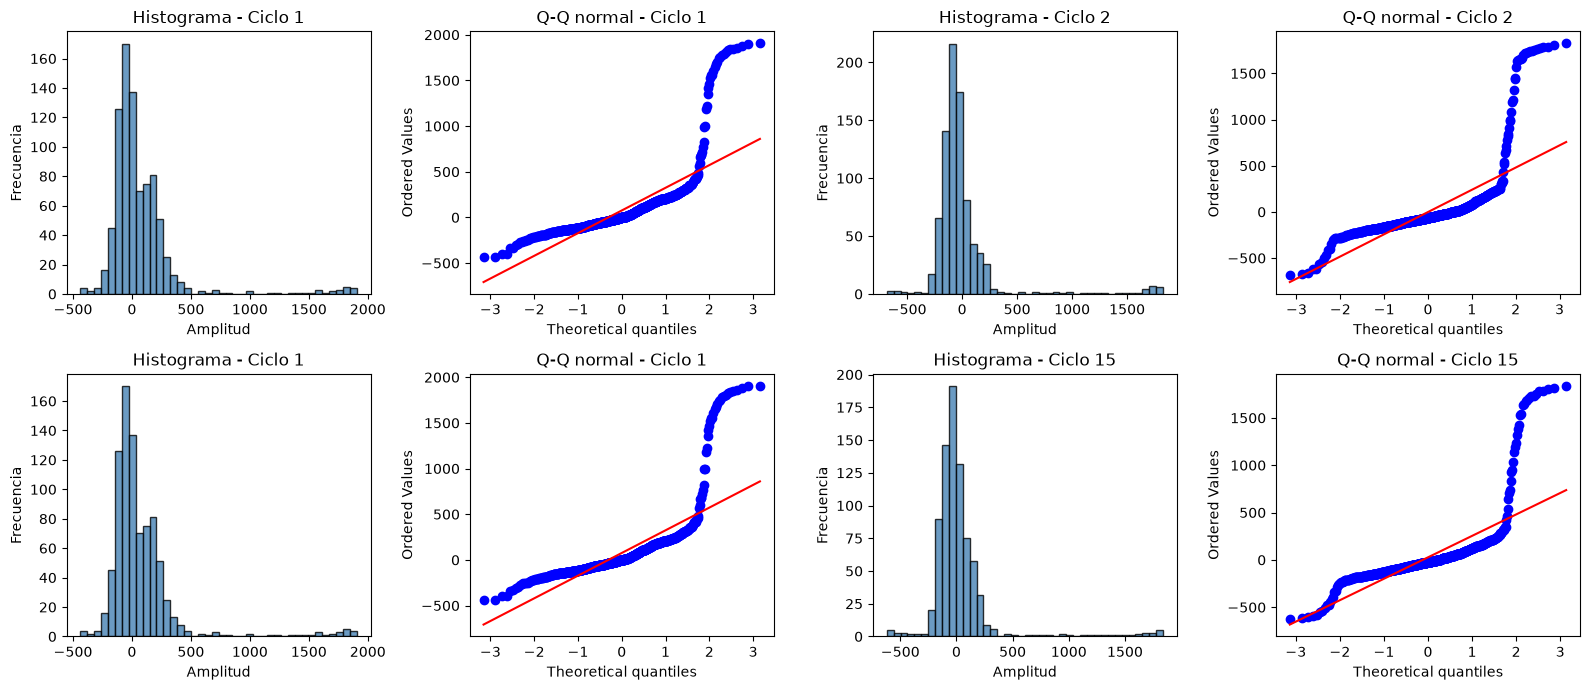

In [27]:
# ============================================================
# Verificación gráfica de la normalidad: histograma + gráfico Q-Q
# ============================================================
from scipy import stats

pares = [(0, 1), (0, 14)]   # (C1 vs C2) y (C1 vs C15)

fig, axs = plt.subplots(2, 4, figsize=(16, 7))

for fila, (a, b) in enumerate(pares):
    for col, idx in enumerate([a, b]):
        c = ciclos[idx]
        axs[fila, 2*col].hist(c, bins=40, color='steelblue', edgecolor='k', alpha=0.8)
        axs[fila, 2*col].set_title(f"Histograma - Ciclo {idx+1}")
        axs[fila, 2*col].set_xlabel("Amplitud")
        axs[fila, 2*col].set_ylabel("Frecuencia")
        stats.probplot(c, dist="norm", plot=axs[fila, 2*col + 1])
        axs[fila, 2*col + 1].set_title(f"Q-Q normal - Ciclo {idx+1}")

plt.tight_layout()
plt.show()

In [28]:
from scipy import stats

def comparar_ciclos(c1, c2, n1, n2, alpha=0.05):
    print("=" * 62)
    print(f"COMPARACIÓN: {n1} vs {n2}")
    print("=" * 62)
    print(f"{n1}: n = {len(c1):4d} | media = {np.mean(c1):8.2f} | var = {np.var(c1, ddof=1):10.2f}")
    print(f"{n2}: n = {len(c2):4d} | media = {np.mean(c2):8.2f} | var = {np.var(c2, ddof=1):10.2f}")

    # --- Supuesto 1: Normalidad (Shapiro-Wilk sobre cada grupo) ---
    # H0: la muestra proviene de una distribución normal
    W1, p1 = stats.shapiro(c1)
    W2, p2 = stats.shapiro(c2)
    print("\n1) NORMALIDAD (Shapiro-Wilk)")
    print(f"   {n1}: W = {W1:.4f}, p = {p1:.3e}  ->  {'normal' if p1 > alpha else 'NO normal'}")
    print(f"   {n2}: W = {W2:.4f}, p = {p2:.3e}  ->  {'normal' if p2 > alpha else 'NO normal'}")
    normalidad = (p1 > alpha) and (p2 > alpha)

    # --- Supuesto 2: Independencia ---
    print("\n2) INDEPENDENCIA")
    print("   Se asume por diseño: son segmentos temporales distintos y no solapados.")

    # --- Supuesto 3: Homocedasticidad (Levene) ---
    # H0: las varianzas de los dos grupos son iguales
    L, pL = stats.levene(c1, c2, center='median')
    print("\n3) HOMOCEDASTICIDAD (Levene)")
    print(f"   W = {L:.4f}, p = {pL:.4f}  ->  {'varianzas iguales' if pL > alpha else 'VARIANZAS DIFERENTES'}")
    homoced = pL > alpha

    # --- Prueba t ---
    # H0: las medias de los dos grupos son iguales
    tstat, pt = stats.ttest_ind(c1, c2, equal_var=homoced)
    tipo = "Student (equal_var=True)" if homoced else "Welch (equal_var=False)"
    print(f"\n4) PRUEBA t - {tipo}")
    print(f"   t = {tstat:.4f}, p = {pt:.4f}  ->  {'NO hay diferencia significativa' if pt > alpha else 'SÍ hay diferencia significativa'}")

    # Tamaño del efecto: mide la MAGNITUD de la diferencia, no solo si existe
    sp = np.sqrt(((len(c1)-1)*np.var(c1, ddof=1) + (len(c2)-1)*np.var(c2, ddof=1)) / (len(c1)+len(c2)-2))
    d = (np.mean(c1) - np.mean(c2)) / sp
    print(f"   Tamaño del efecto (d de Cohen) = {d:.4f}  ->  {'pequeño' if abs(d) < 0.5 else 'moderado/grande'}")

    # --- Alternativa no paramétrica si falla la normalidad ---
    if not normalidad:
        # H0: las dos muestras provienen de la misma distribución
        U, pu = stats.mannwhitneyu(c1, c2, alternative='two-sided')
        print("\n5) NO SE CUMPLE NORMALIDAD -> PRUEBA U DE MANN-WHITNEY")
        print(f"   U = {U:.1f}, p = {pu:.4f}  ->  {'NO hay diferencia significativa' if pu > alpha else 'SÍ hay diferencia significativa'}")
    print()


# Comparación 1: ciclos consecutivos
comparar_ciclos(ciclos[0], ciclos[1], "Ciclo 1", "Ciclo 2")

COMPARACIÓN: Ciclo 1 vs Ciclo 2
Ciclo 1: n =  865 | media =    76.00 | var =  100106.40
Ciclo 2: n =  854 | media =    -1.43 | var =  105048.82

1) NORMALIDAD (Shapiro-Wilk)
   Ciclo 1: W = 0.6144, p = 4.464e-40  ->  NO normal
   Ciclo 2: W = 0.5501, p = 4.382e-42  ->  NO normal

2) INDEPENDENCIA
   Se asume por diseño: son segmentos temporales distintos y no solapados.

3) HOMOCEDASTICIDAD (Levene)
   W = 1.7919, p = 0.1809  ->  varianzas iguales

4) PRUEBA t - Student (equal_var=True)
   t = 5.0117, p = 0.0000  ->  SÍ hay diferencia significativa
   Tamaño del efecto (d de Cohen) = 0.2418  ->  pequeño

5) NO SE CUMPLE NORMALIDAD -> PRUEBA U DE MANN-WHITNEY
   U = 479001.0, p = 0.0000  ->  SÍ hay diferencia significativa



In [29]:
# Comparación 2: ciclos alejados en el tiempo
comparar_ciclos(ciclos[0], ciclos[14], "Ciclo 1", "Ciclo 15")

COMPARACIÓN: Ciclo 1 vs Ciclo 15
Ciclo 1: n =  865 | media =    76.00 | var =  100106.40
Ciclo 15: n =  807 | media =    27.11 | var =   89748.15

1) NORMALIDAD (Shapiro-Wilk)
   Ciclo 1: W = 0.6144, p = 4.464e-40  ->  NO normal
   Ciclo 15: W = 0.5706, p = 1.728e-40  ->  NO normal

2) INDEPENDENCIA
   Se asume por diseño: son segmentos temporales distintos y no solapados.

3) HOMOCEDASTICIDAD (Levene)
   W = 3.6195, p = 0.0573  ->  varianzas iguales

4) PRUEBA t - Student (equal_var=True)
   t = 3.2393, p = 0.0012  ->  SÍ hay diferencia significativa
   Tamaño del efecto (d de Cohen) = 0.1585  ->  pequeño

5) NO SE CUMPLE NORMALIDAD -> PRUEBA U DE MANN-WHITNEY
   U = 397256.0, p = 0.0000  ->  SÍ hay diferencia significativa



**Análisis**

**Normalidad** La prueba de Shapiro-Wilk rechaza la normalidad de forma contundente en los ciclos evaluados: W = 0.6144 (p = 4.46e-40) para el ciclo 1, W = 0.5501 (p = 4.38e-42) para el ciclo 2 y W = 0.5706 (p = 1.73e-40) para el ciclo 15. Valores de W tan alejados de 1 indican una desviación severa, y los gráficos Q-Q muestran el porqué: los puntos siguen la recta teórica en la zona central, pero se desprenden bruscamente hacia arriba a partir del cuantil +1.7, saltando casi en vertical hasta los 1800. Esto responde a la morfología del ECG, que permanece la mayor parte del ciclo en la línea isoeléctrica y solo dedica unas decenas de muestras al complejo QRS, generando una distribución fuertemente leptocúrtica. **El supuesto de normalidad no se cumple, por lo que la prueba t no es válida y la conclusión debe tomarse de la U de Mann-Whitney.**

**Independencia** Se asume por diseño, ya que los ciclos son segmentos temporales distintos y no solapados de la señal.

**Homocedasticidad** La prueba de Levene no rechaza la igualdad de varianzas en ninguna de las dos comparaciones: W = 1.7919 (p = 0.1809) para C1 vs C2 y W = 3.6195 (p = 0.0573) para C1 vs C15. En el segundo caso el valor p queda cerca del umbral de 0.05, lo que se explica por la mayor diferencia entre las varianzas (100.106 frente a 89.748, cerca de un 11 %, contra apenas un 5 % en la primera comparación). Al no rechazarse el supuesto, en ambos casos se aplica la t de Student clásica.

**Resultado de las pruebas** Las dos comparaciones arrojan p < 0.05, es decir, diferencia estadísticamente significativa. Sin embargo, este resultado debe leerse con cuidado por el tamaño de muestra: con n cercano a 850 muestras por ciclo, las pruebas alcanzan una potencia altísima y detectan como significativas diferencias irrelevantes en la práctica. Al cuantificar la magnitud del efecto mediante la d de Cohen se obtienen valores pequeños (alrededor de 0.24 para C1 vs C2 y 0.16 para C1 vs C15). En términos absolutos, la mayor de las dos diferencias de medias (77.43 unidades) representa apenas un 4 % de la amplitud del pico QRS, que supera 1800.

**Qué indica respecto de la estacionariedad??** Si la señal fuera no estacionaria, esperaríamos que la discrepancia *creciera con la separación temporal*: los ciclos alejados deberían diferir más entre sí que los consecutivos. Ocurre exactamente lo contrario en todos los indicadores.

| Indicador | C1 vs C2 (consecutivos) | C1 vs C15 (alejados) |
|---|---|---|
| Diferencia de medias | 77.43 | 48.89 |
| Estadístico t | 5.0117 | 3.2393 |
| Estadístico U | 479.001 | 397.256 |
| Tamaño del efecto (d de Cohen) | 0.24 | 0.16 |

Los ciclos separados por 14 latidos resultan **más parecidos entre sí** que dos latidos consecutivos. Esto descarta la presencia de una tendencia o deriva sistemática en las propiedades estadísticas de la señal: las diferencias detectadas responden a la **variabilidad natural latido a latido** —fluctuaciones del ruido, pequeñas variaciones morfológicas y en la posición exacta del pico R usado para segmentar— y no al paso del tiempo. El hallazgo es consistente con lo observado en el punto anterior, donde las medias de los 15 ciclos oscilaban sin tendencia entre -23.96 y 76.0, y respalda la hipótesis de estacionariedad del ECG.

Finalmente quedan limitadas estas pruebas cuando comparan distribuciones de amplitud y no la estructura temporal de la señal, y que las muestras dentro de un mismo ciclo están autocorrelacionadas, lo cual rompe el supuesto de independencia intra-grupo y afecta la validez de los valores p. Por eso el análisis se complementa con una prueba diseñada específicamente para evaluar estacionariedad: la de Dickey-Fuller.

---

Compruebe los resultados anteriores aplicando una prueba de Dickey-Fuller a la señal
(Estacionariedad) 

In [30]:
import warnings
from statsmodels.tsa.stattools import adfuller

# El criterio AIC descarta por sí solo los modelos degenerados, por lo que
# el aviso de matriz rank-deficient puede silenciarse sin afectar el resultado
warnings.filterwarnings('ignore', message='.*rank-deficient.*')

def dickey_fuller(senal, nombre, alpha=0.05, maxlag=60):
    resultado = adfuller(np.squeeze(senal), maxlag=maxlag, autolag='AIC')
    print("=" * 62)
    print(f"PRUEBA DE DICKEY-FULLER AUMENTADA (ADF) - {nombre}")
    print("=" * 62)
    print(f"Estadístico ADF : {resultado[0]:.6f}")
    print(f"p-valor         : {resultado[1]:.6e}")
    print(f"Rezagos usados  : {resultado[2]}")
    print(f"N observaciones : {resultado[3]}")
    print("Valores críticos:")
    for clave, valor in resultado[4].items():
        print(f"   {clave:>4} : {valor:.4f}")
    if resultado[1] < alpha:
        print(f"\n-> p < {alpha}: se RECHAZA H0 (raíz unitaria). La señal se considera ESTACIONARIA.\n")
    else:
        print(f"\n-> p >= {alpha}: NO se rechaza H0. La señal se considera NO ESTACIONARIA.\n")

dickey_fuller(ecg_sin_filtrar, "ECG sin filtrar")

PRUEBA DE DICKEY-FULLER AUMENTADA (ADF) - ECG sin filtrar
Estadístico ADF : -14.934348
p-valor         : 1.351567e-27
Rezagos usados  : 60
N observaciones : 30659
Valores críticos:
     1% : -3.4306
     5% : -2.8616
    10% : -2.5668

-> p < 0.05: se RECHAZA H0 (raíz unitaria). La señal se considera ESTACIONARIA.



C:\Users\PAULA CAMILA\AppData\Local\Temp\ipykernel_12276\366605346.py:9: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(np.squeeze(senal), maxlag=maxlag, autolag='AIC')


In [31]:
dickey_fuller(ecg_filtrada, "ECG filtrada")

PRUEBA DE DICKEY-FULLER AUMENTADA (ADF) - ECG filtrada
Estadístico ADF : -26.637874
p-valor         : 0.000000e+00
Rezagos usados  : 19
N observaciones : 30700
Valores críticos:
     1% : -3.4306
     5% : -2.8616
    10% : -2.5668

-> p < 0.05: se RECHAZA H0 (raíz unitaria). La señal se considera ESTACIONARIA.



C:\Users\PAULA CAMILA\AppData\Local\Temp\ipykernel_12276\366605346.py:9: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(np.squeeze(senal), maxlag=maxlag, autolag='AIC')


In [32]:
# Tramo correspondiente a los 15 ciclos analizados
tramo_15 = ecg_filtrada[picos_15[0]:picos_15[-1]]
dickey_fuller(tramo_15, "ECG filtrada (tramo de los 15 ciclos)")

PRUEBA DE DICKEY-FULLER AUMENTADA (ADF) - ECG filtrada (tramo de los 15 ciclos)
Estadístico ADF : -20.511372
p-valor         : 0.000000e+00
Rezagos usados  : 19
N observaciones : 13003
Valores críticos:
     1% : -3.4309
     5% : -2.8618
    10% : -2.5669

-> p < 0.05: se RECHAZA H0 (raíz unitaria). La señal se considera ESTACIONARIA.



C:\Users\PAULA CAMILA\AppData\Local\Temp\ipykernel_12276\366605346.py:9: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(np.squeeze(senal), maxlag=maxlag, autolag='AIC')


**Análisis**

**¿Qué prueba realmente el test?** La prueba de Dickey-Fuller aumentada (ADF) plantea como hipótesis nula que **la serie tiene una raíz unitaria**, es decir, que es no estacionaria (tipo caminata aleatoria, donde las perturbaciones se acumulan indefinidamente y la serie no tiende a regresar a un nivel medio). La hipótesis alternativa es que la serie es estacionaria. Por lo tanto, la lógica está invertida respecto de la mayoría de pruebas empleadas hasta aquí: **en este caso se busca rechazar H0** para poder concluir estacionariedad. La decisión se toma con el p-valor (si p < 0.05 se rechaza H0) o, equivalentemente, comparando el estadístico ADF con los valores críticos: si es más negativo que el valor crítico al 5 %, se rechaza H0.

**Sobre la selección del número de rezagos** La prueba ajusta un modelo autorregresivo sobre las diferencias de la serie, y el número de rezagos determina cuánta historia se usa para modelar su estructura. Este parámetro resultó crítico en el caso del ECG: al estar muestreada a 1024 Hz, la señal presenta una autocorrelación muy alta entre muestras vecinas, y una ventana de rezagos demasiado corta no alcanza a capturar esa estructura, dejando los residuos correlacionados y haciendo que la prueba pierda potencia. Por esta razón se dejó que el algoritmo seleccionara el número óptimo mediante el criterio de información de Akaike (AIC), en lugar de fijarlo manualmente. El algoritmo escogió 60 rezagos para la señal sin filtrar y 19 para la filtrada, diferencia coherente con el hecho de que la señal filtrada, al haber perdido las componentes de alta frecuencia, tiene una estructura temporal más simple de modelar.

**Resultados**

| Señal | Estadístico ADF | p-valor | Rezagos | N | Conclusión |
|---|---|---|---|---|---|
| ECG sin filtrar | -14.9343 | 1.35e-27 | 60 | 30.659 | Estacionaria |
| ECG filtrada | -26.6379 | ≈ 0 | 19 | 30.700 | Estacionaria |
| ECG filtrada (tramo 15 ciclos) | -20.5114 | ≈ 0 | 19 | 13.003 | Estacionaria |

En los tres casos el estadístico ADF es mucho más negativo que el valor crítico al 1 % (-3.4306), y los p-valores están muy por debajo de 0.05. **Se rechaza contundentemente la hipótesis nula de raíz unitaria: la señal de ECG se comporta como estacionaria en el sentido de reversión a la media.**

Esto tiene sentido fisiológico y matemático. El ECG es una señal **periódica**: oscila de forma repetitiva alrededor de un nivel base y siempre regresa a él después de cada latido, sin el comportamiento acumulativo y sin rumbo característico de un proceso con raíz unitaria.

**Efecto del filtrado.** Resulta especialmente revelador comparar las dos primeras filas. La señal filtrada arroja un estadístico notablemente más negativo (-26.64) que la señal sin filtrar (-14.93), es decir, **evidencia más fuerte de estacionariedad**. Esto confirma lo observado desde el inicio de la práctica: el filtro eliminó el offset y las variaciones lentas de línea base —atribuibles a la respiración y al movimiento de los electrodos— que constituyen precisamente la principal fuente de comportamiento no estacionario en un registro de ECG. Al remover esas componentes de muy baja frecuencia, la señal quedó centrada y sin deriva, reforzando su carácter estacionario.

El tramo correspondiente a los 15 ciclos analizados también resulta estacionario (-20.5114), lo cual valida que las conclusiones extraídas en los puntos anteriores se obtuvieron sobre un segmento de señal efectivamente estable.

**Consistencia con el análisis anterior** Los tres análisis apuntan en la misma dirección, por caminos distintos y con alcances distintos:

| Análisis | Qué evalúa | Resultado | Conclusión |
|---|---|---|---|
| Medias y varianzas de 15 ciclos | Estadísticos entre segmentos | Sin deriva sistemática | Indicio de estacionariedad |
| Prueba U de Mann-Whitney | Distribución de dos ciclos concretos | Diferencia significativa pero de magnitud despreciable, y menor entre ciclos alejados | Indicio de estacionariedad |
| Dickey-Fuller | Presencia de raíz unitaria en toda la serie | p << 0.05 en las tres señales | Estacionariedad confirmada |

La prueba ADF es la más concluyente de las tres, porque evalúa la serie completa y su estructura temporal en lugar de comparaciones puntuales entre segmentos, y porque no depende del supuesto de normalidad que las pruebas anteriores incumplían.

**Matiz importante** Que el ADF indique estacionariedad no significa que el ECG sea estrictamente estacionario. Como señala el marco teórico de la guía, las bioseñales no lo son en sentido estricto: cambios en la respiración, el estado emocional o la actividad del sujeto modifican la fisiología y, con ella, las propiedades de la señal. Lo que puede afirmarse es que **en la ventana de tiempo analizada** el ECG es lo bastante estable como para tratarlo como estacionario, que es el supuesto habitual bajo el cual se aplican las técnicas de procesamiento posteriores. Además, el ADF detecta un tipo específico de no estacionariedad (la raíz unitaria); una señal puede ser no estacionaria por otras vías —por ejemplo, un cambio de varianza sin cambio de media— que esta prueba no captaría.

---

## Referencias



- SciPy. *Statistical functions (scipy.stats)*. https://docs.scipy.org/doc/scipy/reference/stats.html
- statsmodels. *statsmodels.tsa.stattools.adfuller*. https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html
- SciPy. *scipy.signal.find_peaks*. https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html
- Ciencia de Datos. *Prueba t en Python*. https://www.cienciadedatos.net/documentos/pystats10-t-test-python.html
- Ciencia de Datos. *Test de homocedasticidad y heterocedasticidad en Python*. https://www.cienciadedatos.net/documentos/pystats07-test-homocedasticidad-heterocedasticidad-python.html
- Yao, J. M. *Nonparametric Statistical Significance Tests*. https://jmyao17.github.io/Statistics/Nonparametric_Statistical_Significance_Tests.html
- Haslwanter, T. *ISP_checkNormality.py*. GitHub: statsintro_python. https://github.com/thomashaslwanter/statsintro_python
